In [19]:
import rosalia as rs
import sys
# sys.path.append("/Users/aborlaff/NASA/EPHESSOS/")


In [20]:
import ephessos as ep
print(ep.__file__)


/Users/aborlaff/NASA/EPHESSOS/ephessos/__init__.py


In [21]:
class exposure():
    import numpy as np 
    
    def __init__(self, filename):
        exposure_identity = rs.utils.exposure_inspector(filename, lite=True)
        
        self.FILENAME = exposure_identity['FILENAME']
        self.TELESCOP = exposure_identity['TELESCOP']
        self.INSTRUME = exposure_identity['INSTRUME']
        self.DETECTOR = exposure_identity['DETECTOR']
        self.RA_TARG = exposure_identity['RA_TARG']
        self.DEC_TARG = exposure_identity['DEC_TARG']
        self.EXPSTART = exposure_identity['EXPSTART']
        self.EXPTIME = exposure_identity['EXPTIME']
        self.BUNIT = exposure_identity['BUNIT']
        self.EXPSTART_ISOT = exposure_identity['EXPSTART_ISOT']
        self.PA = exposure_identity['PA']
        self.SCA = exposure_identity['SCA']
        self.HST_TYPE = exposure_identity['HST_TYPE']
        self.FILTER = exposure_identity['FILTER']
        self.FILTER_IDENTITY = exposure_identity['FILTER_IDENTITY']
        self.PHYSPIX = exposure_identity['PHYSPIX']
        self.PIXSCALE = exposure_identity['PIXSCALE']
        self.SCIEXTS = exposure_identity['SCIEXTS']
        self.DATA_SHAPE = exposure_identity['DATA_SHAPE']
        self.ASTROPYWCS = exposure_identity['ASTROPYWCS']
        self.FILETYPE = exposure_identity['FILETYPE']
        self.XYZ_HELIO_POS = exposure_identity['XYZ_HELIO_POS']
        self.FPA_NEAR_RADIUS = self.get_max_angular_size()/4

    def get_detector_corners(self):
        detector_corners = []
        for i in range(len(self.SCIEXTS)):
            detector_corners.append(rs.detectors.get_detector_corners(self.ASTROPYWCS[i]))
        return(detector_corners)
    
    def get_max_angular_size(self):
        return(rs.utils.find_max_angular_size_of_image(wcs=self.ASTROPYWCS, ra_cen=self.RA_TARG, dec_cen=self.DEC_TARG))
    

    def plot_footprint(self, ax=None, color='red', label=None, **kwargs):
        import numpy as np
        import matplotlib.pyplot as plt
        
        ra_dec_constraints = rs.gaia.find_ra_dec_constraints(self.RA_TARG, self.DEC_TARG, radius=self.FPA_NEAR_RADIUS, verbose=False)
        exp_corners = self.get_detector_corners()

        if ax is None:
            fig, ax = plt.subplots(figsize=(8,8))
        for i in range(len(self.SCIEXTS)):
            x = np.array(exp_corners[i]["corners_world"][:,0].tolist() + [exp_corners[i]["corners_world"][0,0]])
            y = np.array(exp_corners[i]["corners_world"][:,1].tolist() + [exp_corners[i]["corners_world"][0,1]])
            ax.plot(x, y, color=color, label=label, **kwargs)
            ax.set_xlim(ra_dec_constraints["ra_max"], ra_dec_constraints["ra_min"])
            ax.set_ylim(ra_dec_constraints["dec_min"], ra_dec_constraints["dec_max"])
            ax.set_xlabel("Right Ascension (degree)")
            ax.set_ylabel("Declination (degree)")
        return(ax)
    
    def find_nearby_ssos(self):
        import ephessos as ep 
        sso_cone_search = ep.core.cone_search(ra=self.RA_TARG, dec=self.DEC_TARG, epoch=self.EXPSTART, search_radius=self.FPA_NEAR_RADIUS, verbose=False)
        return(sso_cone_search)

    def get_nearby_sources(self, g_mag_max=15):
        hybrid_catalog = rs.psf.get_hybrid_catalog(ra=self.RA_TARG, dec=self.DEC_TARG,
                                                   radius=1,
                                                   lambda_ref=lambda_ref,
                                                   MJD=MJD,
                                                   observer=telescope,
                                                   g_mag_max = g_mag_max,
                                                   verbose=verbose,
                                                   query_filename=source_catalog_filename)


/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI_F129_RA_085.533_DEC_-50.397_MJD_61365.00000_PA_142.21.fits
Using Minor Planet Center cached file: Last: 2026-04-28T15:04:43.719
No matches found in cone search.
/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI_F129_RA_096.027_DEC_-52.832_MJD_61365.00000_PA_142.21.fits
Using Minor Planet Center cached file: Last: 2026-04-28T15:04:43.719
No matches found in cone search.
/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI_F129_RA_087.175_DEC_-49.404_MJD_61365.00000_PA_142.21.fits
Using Minor Planet Center cached file: Last: 2026-04-28T15:04:43.719
No matches found in cone search.
/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI_F129_RA_085.480_DEC_-50.356_MJD_61365.00000_PA_142.21.fits
Using Minor Planet Center cached file: Last: 2026-04-28T15:04:43.719
No matches found in cone search.
/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI_F129_RA_085.532_DEC_-50.398_MJD_61365.00000_PA_142.21.fits
Using Minor Planet Center cached

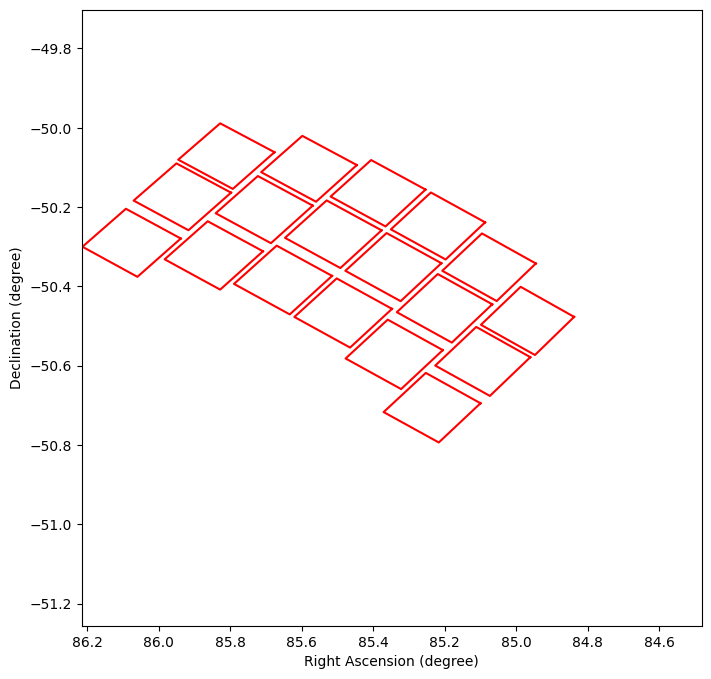

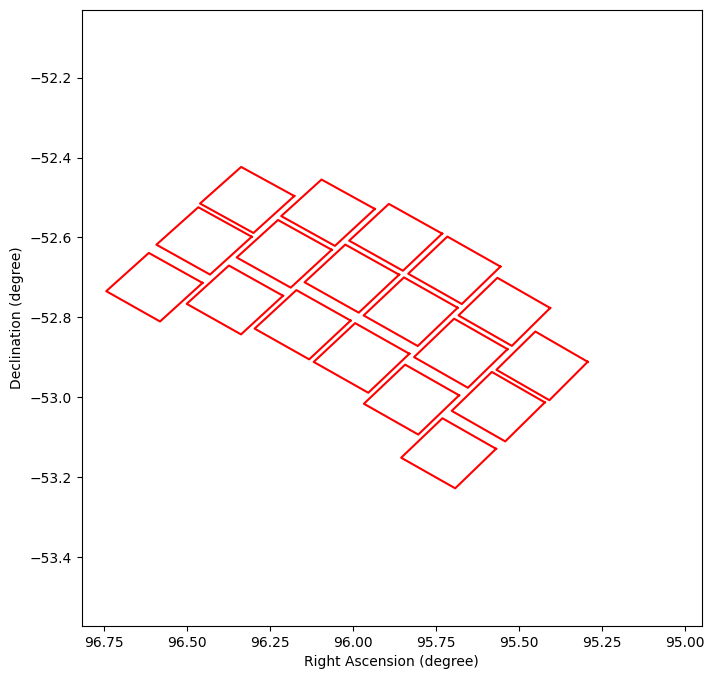

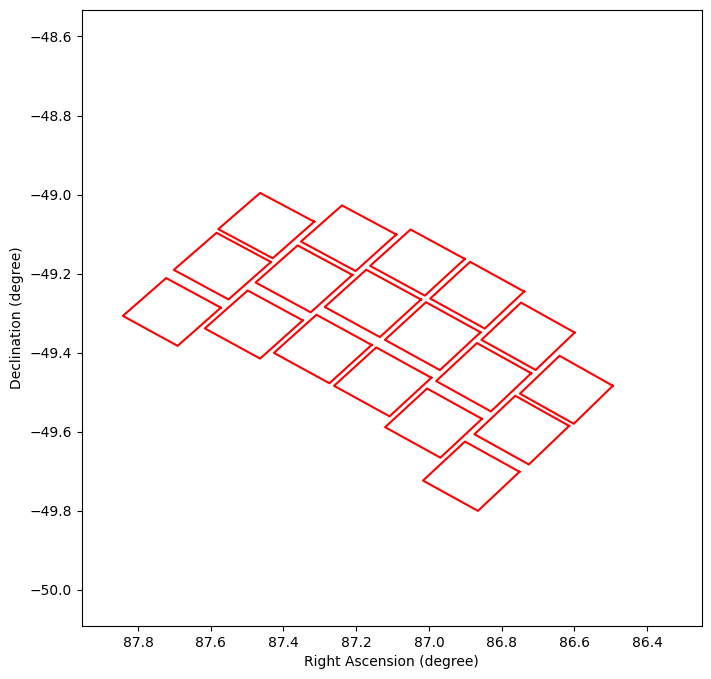

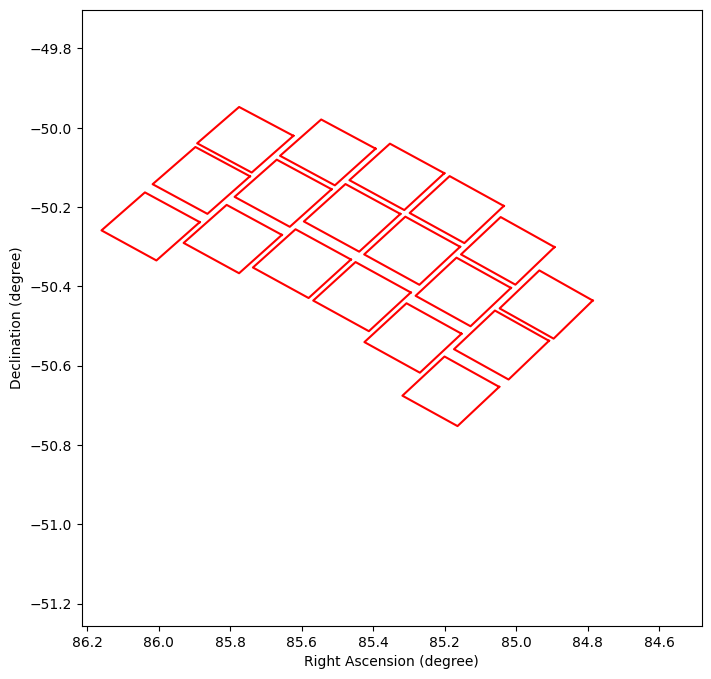

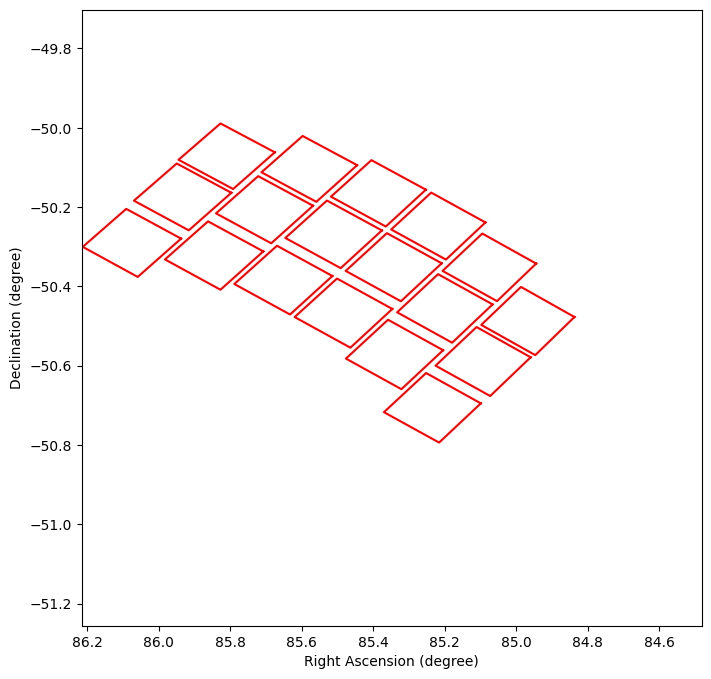

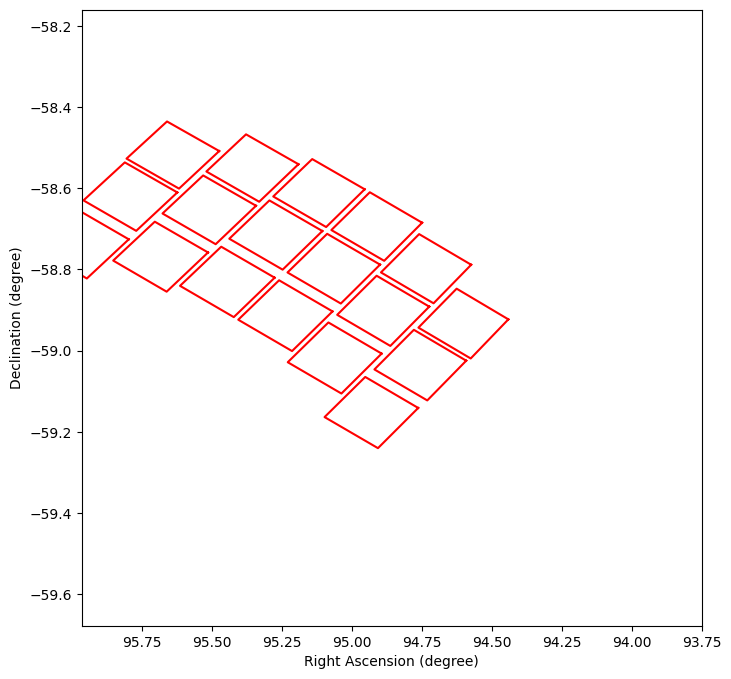

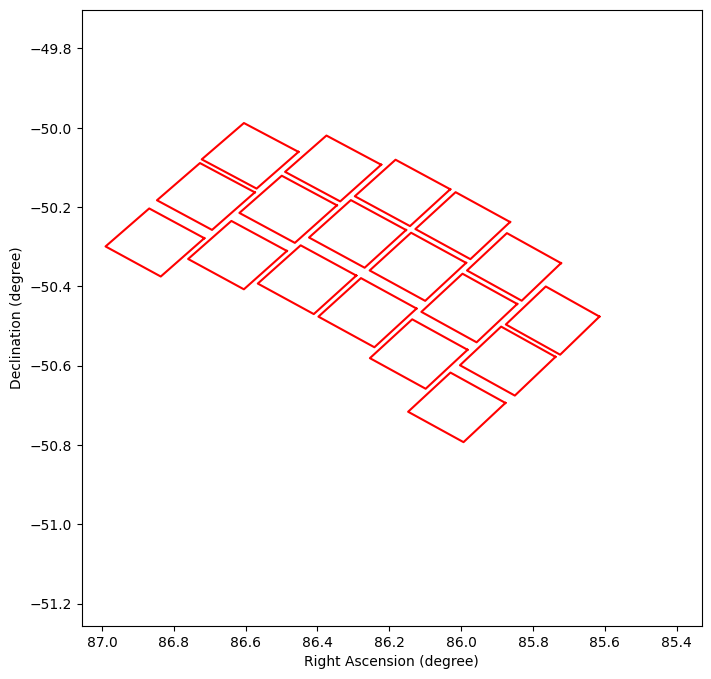

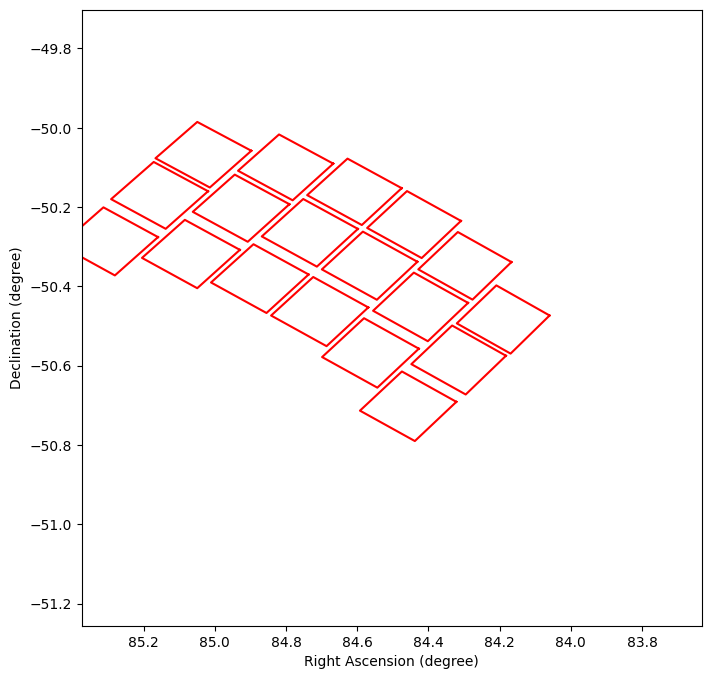

In [22]:
import glob
roman_fits = glob.glob("/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI*[0-9].fits")

for i in range(len(roman_fits)):
    print(roman_fits[i])
    roman_exposure = exposure(roman_fits[i])
    roman_exposure.plot_footprint()
    roman_exposure.find_nearby_ssos()

In [23]:
# roman_exposure.get_detector_corners()
rs.utils.find_max_angular_size_of_image(wcs=roman_exposure.ASTROPYWCS)    

In [24]:
ep.core.get_last_mpcorb()

Using Minor Planet Center cached file: Last: 2026-04-28T15:04:43.719


'/Users/aborlaff/NASA/EPHESSOS/ephessos/MPCORB.DAT'

In [25]:
exp_corners[0]["corners_world"][:,0].tolist()

NameError: name 'exp_corners' is not defined

In [ ]:
import pympc 
pympc.update_catalogue()